Building upon the foundation of LeNet, the AlexNet architecture pioneered the era of deep learning， introducing a deeper network structure. By integrating additional convolutional layers and Dropout regularization to prevent overfitting, the model reachs an accuracy of over 98.8% on the Fashion-MNIST task.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms   
import matplotlib.pyplot as plt 

In [2]:
alex_transform = transforms.Compose([
    transforms.Resize(224),             # 关键：将 28x28 缩放到 224x224
    transforms.ToTensor(),              # 转化为张量
    transforms.Normalize((0.5,), (0.5,)) # 标准化
])

In [3]:
batch_size = 128

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=alex_transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=alex_transform)

train_iter = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [4]:


net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256, kernel_size=5, padding=2),#输出维度不变
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(256, 384, kernel_size=3, padding=1), 
    nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), 
    nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    nn.Linear(6400, 4096), 
    nn.ReLU(),
    nn.Dropout(p=0.5),#防止过拟合
    nn.Linear(4096, 4096), 
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10))

In [5]:
def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

net.apply(init_weights) 

Sequential(
  (0): Conv2d(1, 96, kernel_size=(11, 11), stride=(4, 4), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Linear(in_features=6400, out_features=4096, bias=True)
  (15): ReLU()
  (16): Dropout(p=0.5, inplace=False)
  (17): Linear(in_features=4096, out_features=4096, bias=True)
  (18): ReLU()
  (19): Dropout(p=0.5, inplace=False)
  (20): Linear(in_featu

In [6]:
X = torch.randn(1, 1, 224, 224)
for layer in net:
    X=layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

In [7]:
def plot_history(loss_history, acc_history):
    epochs = range(1, len(loss_history) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_history, 'r-o', label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_history, 'b-o', label='Train Acc')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [8]:
def train_AlexNet(net, train_iter, test_iter, num_epochs, lr, device):
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    
    train_loss_history = []
    train_acc_history = []

    for epoch in range(num_epochs):
        net.train()
        total_loss, total_acc, n = 0.0, 0.0, 0
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            
            optimizer.zero_grad()
            l.backward()
            optimizer.step()
            
            total_loss += l.item() * y.shape[0]
            total_acc += (y_hat.argmax(dim=1) == y).sum().item()
            n += y.shape[0]
        
        epoch_loss = total_loss / n
        epoch_acc = total_acc / n

        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        print(f'Epoch {epoch+1}: Loss {epoch_loss:.3f}, Train Acc {epoch_acc    :.3f}')

    plot_history(train_loss_history, train_acc_history)


training on cuda
Epoch 1: Loss 0.591, Train Acc 0.797
Epoch 2: Loss 0.327, Train Acc 0.881
Epoch 3: Loss 0.274, Train Acc 0.900
Epoch 4: Loss 0.238, Train Acc 0.913
Epoch 5: Loss 0.210, Train Acc 0.924
Epoch 6: Loss 0.187, Train Acc 0.932
Epoch 7: Loss 0.164, Train Acc 0.939
Epoch 8: Loss 0.142, Train Acc 0.948
Epoch 9: Loss 0.123, Train Acc 0.954
Epoch 10: Loss 0.108, Train Acc 0.960
Epoch 11: Loss 0.093, Train Acc 0.965
Epoch 12: Loss 0.080, Train Acc 0.971
Epoch 13: Loss 0.069, Train Acc 0.974
Epoch 14: Loss 0.058, Train Acc 0.978
Epoch 15: Loss 0.052, Train Acc 0.981
Epoch 16: Loss 0.048, Train Acc 0.983
Epoch 17: Loss 0.038, Train Acc 0.986
Epoch 18: Loss 0.040, Train Acc 0.985
Epoch 19: Loss 0.033, Train Acc 0.988
Epoch 20: Loss 0.031, Train Acc 0.988


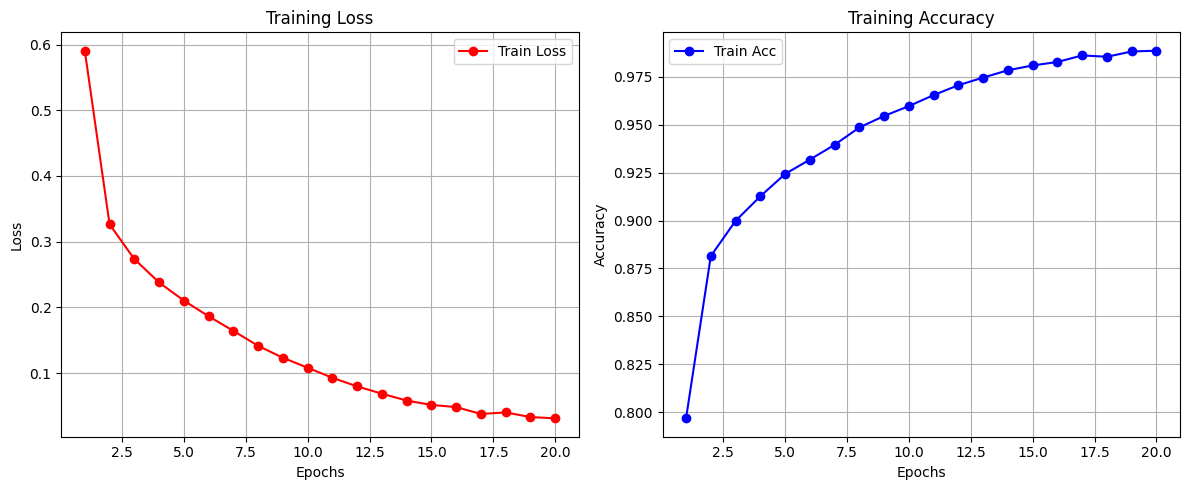

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr, num_epochs = 0.0001, 20
train_AlexNet(net, train_iter, test_iter, num_epochs=num_epochs, lr=lr, device=device)